# Line-by-Line Guide to `pd.read_excel()`
## Every Line of Code Explained — Using `sample.xlsx`
### Prodigy Training Hub

---

> **How this notebook works:**  
> Every single line of code is explained **before** it runs.  
> Read the explanation, then run the code cell.  
> The dataset is `sample.xlsx` — four sheets: **Sales, Finance, Health, Inventory**.

---

## The Dataset at a Glance

| Sheet | Rows | Key Columns |
|---|---|---|
| **Sales** | 320 | OrderID, OrderDate, Customer, Region, SalesRep, Product, UnitPrice, TotalAmount, Status, Rating |
| **Finance** | 215 | TransactionID, TransactionDate, Department, Amount, Currency, ApprovedBy |
| **Health** | 265 | PatientID, AdmissionDate, PatientAge, Diagnosis, BP_Systolic, BP_Diastolic, Outcome |
| **Inventory** | 100 | ItemCode, ItemName, StockQty, CostPrice, SellingPrice *(first 3 rows are title rows)* |

Every sheet has **missing values**, **dirty data**, and **duplicate rows** — just like real-world files.

---

---
# SECTION 0: Setup

---

Before we read any Excel file, we must import the libraries we need.  
This is always the very first cell in any data analysis notebook.

---

### Line-by-Line Explanation

```python
import pandas as pd
```
**What it does:** Loads the entire Pandas library into your Python session.  
**Why `pd`?** `pd` is a shorthand alias — a nickname — that every data analyst in the world uses for Pandas. Instead of typing `pandas.read_excel()` every time, you just type `pd.read_excel()`. It is a global community convention.

---

```python
import numpy as np
```
**What it does:** Loads NumPy — the numerical computing library that Pandas is built on top of.  
**Why `np`?** Same reason as `pd` — it is the universal alias.  
**When do we use it?** When we need `np.nan` (a missing value), `np.where()` (conditional logic), or any mathematical array operation.

---

```python
import matplotlib.pyplot as plt
```
**What it does:** Loads the Matplotlib plotting library — the foundation for all charts in Python.  
**Why `plt`?** Again — universal alias. All charts in this notebook use `plt`.

---

```python
import warnings
warnings.filterwarnings('ignore')
```
**What it does:** Tells Python to suppress minor warning messages that Pandas sometimes prints.  
**Why?** They do not affect results — they just clutter the notebook output. We silence them so students see only the important output.

---

```python
%matplotlib inline
```
**What it does:** A Jupyter "magic command" (starts with `%`) that tells Jupyter to display charts directly inside the notebook, below the code cell that created them.  
**Important:** This only works inside Jupyter / JupyterLab / Google Colab — not in plain `.py` scripts.

---

```python
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:,.2f}'.format)
```
**What it does:** Configures how Pandas displays DataFrames in the notebook.  
- `max_columns=20` — show up to 20 columns before truncating with `...`  
- `max_rows=30` — show up to 30 rows before truncating  
- `width=120` — use 120 characters of horizontal width  
- `float_format` — format all floating-point numbers with commas and 2 decimal places (e.g., `318,717.72` instead of `318717.7234`)

In [1]:
import pandas as pd            # Pandas — data analysis library, aliased as pd
import numpy as np             # NumPy — numerical library, aliased as np
import matplotlib.pyplot as plt # Matplotlib — plotting library, aliased as plt
import warnings                # warnings — built-in Python module to control warning messages

warnings.filterwarnings('ignore')  # Suppress minor warning messages from Pandas/NumPy
%matplotlib inline

# Configure how DataFrames are displayed
pd.set_option('display.max_columns', 20)              # Show up to 20 columns
pd.set_option('display.max_rows', 30)                 # Show up to 30 rows
pd.set_option('display.width', 120)                   # Use 120-character display width
pd.set_option('display.float_format', '{:,.2f}'.format) # Format floats: 318,717.72

# Confirm the libraries are loaded
print("Pandas  :", pd.__version__)   # pd.__version__ is the installed version number
print("NumPy   :", np.__version__)
print("Ready!")

Pandas  : 2.3.1
NumPy   : 2.3.1
Ready!


---
# SECTION 1: Inspect the Excel File Before Reading

---

Before reading any data, professional analysts always **inspect the file first** to understand its structure.  
`pd.ExcelFile()` opens the workbook and lets you peek at its sheet names — without loading any data.

---

### Line-by-Line Explanation

```python
xl_file = pd.ExcelFile('sample.xlsx')
```
**What it does:** Opens the Excel file `sample.xlsx` and stores a reference to it in the variable `xl_file`.  
**Important:** This does NOT load the data into memory yet. It only opens the file handle — like opening a book to the table of contents without reading any pages.  
**The variable name:** `xl_file` is just a name we chose. You can use any valid Python variable name.

---

```python
print("Workbook:", 'sample.xlsx')
```
**What it does:** Prints the filename as a label. Just a reminder of which file we are working with.

---

```python
print("Number of sheets:", len(xl_file.sheet_names))
```
**What it does:** `xl_file.sheet_names` is a list of all sheet names in the workbook.  
`len()` counts how many items are in that list.  
So this prints: `Number of sheets: 4`

---

```python
for i, name in enumerate(xl_file.sheet_names):
```
**What it does:** A `for` loop that goes through every sheet name.  
`enumerate()` gives us both the **index number** (0, 1, 2...) and the **value** (sheet name) at the same time.  
`i` holds the index; `name` holds the sheet name.

---

```python
    print(f"  [{i}] {name}")
```
**What it does:** For each sheet, prints its index in square brackets and its name.  
`f"..."` is an f-string — Python's way of embedding variables inside a string using `{}`.  
Output will be: `[0] Sales`, `[1] Finance`, etc.

In [2]:
# Open the workbook to inspect its structure — no data is loaded yet
xl_file = pd.ExcelFile('sample.xlsx')  # pd.ExcelFile() opens the file without loading data

print("Workbook:", 'sample.xlsx')                     # Print the file name as a label
print("Number of sheets:", len(xl_file.sheet_names))  # len() counts items in the list
print()

# Loop through all sheet names and print each one with its index
for i, name in enumerate(xl_file.sheet_names):  # enumerate() gives (index, value) pairs
    print(f"  [{i}] {name}")                    # f-string: embed variables inside {}

Workbook: sample.xlsx
Number of sheets: 4

  [0] Sales
  [1] Finance
  [2] Health
  [3] Inventory


---
# SECTION 2: Reading the First Sheet (Default Behaviour)

---

`pd.read_excel()` is the main function for reading Excel files. By default it reads the **first sheet**.

---

### Line-by-Line Explanation

```python
df = pd.read_excel('sample.xlsx')
```
**`pd.read_excel`** — calls the read_excel function from the Pandas library.  
**`'sample.xlsx'`** — the filename in quotes. This is the first and only **required** argument. All others are optional.  
**`df =`** — stores the result (a DataFrame) in a variable we named `df`. By convention, `df` stands for "DataFrame". You could name it anything — `sales`, `data`, `my_table` — but `df` is universally understood.  
**What happens behind the scenes:** Pandas opens the file, reads the first sheet (index 0), detects column names from the first row, guesses each column's data type, and returns a DataFrame.

---

```python
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
```
**`df.shape`** — a tuple `(rows, columns)` describing the size of the DataFrame.  
**`df.shape[0]`** — the first element of the tuple = number of rows.  
**`df.shape[1]`** — the second element = number of columns.  
**`f"Shape: ..."` ** — an f-string printing both numbers in a readable sentence.

---

```python
print(df.head())
```
**`df.head()`** — shows the first 5 rows of the DataFrame.  
**Why 5?** That is the default. You can change it: `df.head(10)` shows 10 rows.  
**Why use it?** It gives you a quick visual confirmation that the data loaded correctly — column names, values, and types all visible at a glance.  
This is the **very first thing** you do after loading any dataset.

In [3]:
# Read the first sheet of the Excel file — sheet_name=0 is the default
df = pd.read_excel('sample.xlsx')  # reads first sheet (Sales), stores as DataFrame named df

# Print the shape of the loaded DataFrame
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
# df.shape returns a tuple (rows, cols) — [0] is rows, [1] is columns
print()

# Show the first 5 rows — always do this immediately after loading
print("=== First 5 rows (df.head()) ===")
print(df.head())  # head() defaults to 5 rows; head(10) gives 10 rows

Shape: 320 rows x 13 columns

=== First 5 rows (df.head()) ===
   OrderID   OrderDate     Customer Region       SalesRep      Channel Product  Quantity  UnitPrice Discount_Pct  \
0  ORD1000  2024-01-05  Customer_42  South  Tunde Adeyemi  Phone Order  Laptop         3 309,402.74            0   
1  ORD1001  2024-01-06  Customer_11  South  Tunde Adeyemi      Partner  Tablet         5 127,500.91           10   
2  ORD1002  2024-01-08  Customer_42  North     Ngozi Dike      Walk-in  Laptop         4        NaN            5   
3  ORD1003  2024-01-09  Customer_57   East    Aisha Garba       Online   Phone         3  76,285.93           20   
4  ORD1004  2024-01-11  Customer_77  South     Ngozi Dike      Walk-in  Laptop         2 397,280.17           15   

   TotalAmount     Status  Rating  
0   928,208.22  Delivered    5.00  
1   573,754.10  Delivered    2.00  
2 1,486,388.51   Returned    1.00  
3   183,086.23  Delivered    1.00  
4   675,376.29   Returned     NaN  


---
### Line-by-Line Explanation — df.info()

```python
df.info()
```
**What it does:** Prints a comprehensive summary of the entire DataFrame in one call. It shows:
- **RangeIndex** — total number of rows
- **Column name** — each column's label
- **Non-Null Count** — how many values in that column are NOT missing (not NaN)
- **Dtype** — the data type Pandas assigned to each column

**How to read the output:**  
If a column has `300 non-null` out of 320 rows, it means **20 values are missing** (NaN).  
The `dtype` column tells you:
- `object` = text / mixed content (strings)
- `int64` = whole numbers
- `float64` = decimal numbers
- `datetime64[ns]` = dates and times
- `bool` = True/False

**Why is this important?** This is the fastest way to spot data quality issues. You can see missing values AND wrong data types in a single command. Every analyst runs `df.info()` immediately after loading.

In [4]:
# df.info() — the most informative single command for understanding a DataFrame
print("=== df.info() ===")
df.info()
# Read the output column by column:
# - Non-Null Count tells you how many values are present (NOT missing)
# - Dtype tells you what type Pandas assigned to each column
# - If Non-Null Count < total rows — that column has missing values

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       320 non-null    object 
 1   OrderDate     320 non-null    object 
 2   Customer      311 non-null    object 
 3   Region        320 non-null    object 
 4   SalesRep      302 non-null    object 
 5   Channel       320 non-null    object 
 6   Product       320 non-null    object 
 7   Quantity      320 non-null    int64  
 8   UnitPrice     306 non-null    float64
 9   Discount_Pct  320 non-null    object 
 10  TotalAmount   310 non-null    float64
 11  Status        320 non-null    object 
 12  Rating        283 non-null    float64
dtypes: float64(3), int64(1), object(9)
memory usage: 32.6+ KB


---
### Line-by-Line Explanation — df.describe()

```python
df.describe()
```
**What it does:** Computes summary statistics for every **numeric column** in the DataFrame.  
The statistics it shows:

| Statistic | Meaning |
|---|---|
| `count` | Number of non-missing values |
| `mean` | Average value |
| `std` | Standard deviation — how spread out the values are |
| `min` | Smallest value |
| `25%` | 25th percentile (first quartile) |
| `50%` | Median (middle value) |
| `75%` | 75th percentile (third quartile) |
| `max` | Largest value |

**How to use it for data quality checks:**  
- If `min` is an impossible negative number (e.g., `-99`) → dirty data  
- If `max` is an impossible outlier (e.g., `999` for age) → dirty data  
- If `count` is less than the total rows → there are missing values  
- If `mean` and `50%` (median) are very different → the data is skewed by outliers

In [5]:
# df.describe() — statistical summary of all numeric columns
print("=== df.describe() ===")
print(df.describe())
# Look at each column's min and max to spot impossible values (outliers / dirty data)
# Look at 'count' — if count < total rows, that column has missing values
# Compare mean vs 50% (median) — big difference means the data is skewed

=== df.describe() ===
       Quantity  UnitPrice  TotalAmount  Rating
count    320.00     306.00       310.00  283.00
mean       2.60 118,812.25   286,295.28    3.14
std        1.33 106,944.29   316,076.08    1.43
min        1.00  12,918.91    12,052.53    1.00
25%        2.00  42,165.09    76,271.28    2.00
50%        2.00  94,701.27   183,086.23    3.00
75%        4.00 141,318.08   388,259.71    4.00
max        5.00 419,683.65 1,721,659.55    5.00


---
# SECTION 3: Reading a Specific Sheet

---

### Line-by-Line Explanation

```python
df_finance = pd.read_excel('sample.xlsx', sheet_name='Finance')
```
**`sheet_name='Finance'`** — the `sheet_name` parameter tells Pandas **which sheet** to load.  
Here we pass the sheet name as a string: `'Finance'`.  
**Why use the name instead of an index number?**  
Using the name is safer. If someone rearranges sheets in the workbook, the name still works correctly. If you used `sheet_name=1` (index), it would silently load the wrong sheet after rearrangement.  
**`df_finance =`** — we give this DataFrame a more specific name to distinguish it from `df` (which holds Sales data). Descriptive variable names prevent confusion when you have multiple DataFrames open.

---

```python
print(f"Shape: {df_finance.shape}")
```
**`df_finance.shape`** — because shape is a tuple `(rows, cols)`, printing it directly shows e.g. `(215, 10)`.  
This is a quick sanity check — confirm the right number of rows and columns loaded.

---

```python
print(df_finance.head(6))
```
**`head(6)`** — shows the first 6 rows. We ask for 6 (instead of the default 5) because the Finance sheet has wide rows and we want a representative sample.

---

```python
df_health = pd.read_excel('sample.xlsx', sheet_name=2)
```
**`sheet_name=2`** — read by **index number** (0=Sales, 1=Finance, 2=Health, 3=Inventory).  
Index 2 is the third sheet — Health.  
**When is this useful?** When writing scripts that process any workbook passed to them, where sheet names are unknown in advance.

In [6]:
# Read the Finance sheet by its NAME — safest approach
df_finance = pd.read_excel('sample.xlsx', sheet_name='Finance')
# sheet_name='Finance' — loads only the Finance sheet, ignores all others

print("=== Finance Sheet ===")
print(f"Shape: {df_finance.shape}")  # (215, 10) — 215 rows, 10 columns
print()
print(df_finance.head(6))            # Show first 6 rows to inspect the data

=== Finance Sheet ===
Shape: (215, 10)

  TransactionID TransactionDate Department  ExpenseType     Amount Currency ApprovedBy Approved BudgetCode Quarter
0      TXN02000      2024-01-01  Marketing     Supplies 318,717.72      GBP        CEO      NaN     BC-815      Q1
1      TXN02001      2024-01-02        NaN     Supplies 181,407.54      GBP        CFO      Yes     BC-827      Q1
2      TXN02002      2024-01-04         HR     Supplies 314,868.73      NGN        CEO      Yes     BC-573      Q1
3      TXN02003      2024-01-06  Marketing       Salary 126,671.82      NGN    Manager      Yes     BC-688      Q1
4      TXN02004      2024-01-08         IT  Maintenance 374,741.73      USD    Manager      Yes     BC-145      Q1
5      TXN02005      2024-01-10      Admin  Consultancy  49,350.85      NGN        HOD      Yes     BC-496      Q1


In [7]:
# Read the Health sheet by its INDEX NUMBER
df_health = pd.read_excel('sample.xlsx', sheet_name=2)
# sheet_name=2 — loads the third sheet (0=Sales, 1=Finance, 2=Health, 3=Inventory)

print("=== Health Sheet (loaded by index=2) ===")
print(f"Shape: {df_health.shape}")
print()
print(df_health.head(6))

=== Health Sheet (loaded by index=2) ===
Shape: (265, 13)

  PatientID AdmissionDate DischargeDate     Hospital       Ward  PatientAge  Gender     Diagnosis  BP_Systolic  \
0  PAT03000    2024-01-01    2024-01-04    FMC Abuja        ICU      999.00    Male      Diabetes          NaN   
1  PAT03001    2024-01-02    2024-01-18    FMC Abuja   Surgical       29.00    Male       Anaemia       163.00   
2  PAT03002    2024-01-03    2024-01-17    FMC Abuja   Surgical       22.00    Male  Hypertension       123.00   
3  PAT03003    2024-01-05    2024-01-07   UNTH Enugu  Maternity       57.00    Male      Fracture       125.00   
4  PAT03004    2024-01-06    2024-01-09   LUTH Lagos        ICU       22.00  Female      COVID-19       160.00   
5  PAT03005    2024-01-08    2024-02-01  ABUTH Zaria        ICU       47.00    Male       Anaemia       119.00   

  BP_Diastolic  LengthOfStay     Outcome InsuranceType  
0          101             3    Referred       Private  
1           87            16

---
# SECTION 4: Reading All Sheets at Once (`sheet_name=None`)

---

### Line-by-Line Explanation

```python
all_sheets = pd.read_excel('sample.xlsx', sheet_name=None)
```
**`sheet_name=None`** — passing `None` (Python's null value, not a string) is a special instruction:  
*"Read every single sheet in this workbook."*  
**What it returns:** NOT a single DataFrame — it returns a Python **dictionary**.  
A dictionary maps keys to values. Here:  
- **Keys** = sheet names (strings like `'Sales'`, `'Finance'`)  
- **Values** = DataFrames (one per sheet)

Think of it like a filing cabinet: `all_sheets` is the cabinet, and each drawer is labelled with a sheet name. You pull a drawer to get its DataFrame.

---

```python
print("Return type:", type(all_sheets))
```
**`type()`** — Python's built-in function that tells you what kind of object a variable holds.  
This will print: `<class 'dict'>` — confirming we got a dictionary back, not a DataFrame.

---

```python
for name, dfs in all_sheets.items():
```
**`all_sheets.items()`** — a dictionary method that returns all key-value pairs as tuples: `('Sales', DataFrame), ('Finance', DataFrame), ...`  
**`name`** receives the key (sheet name string).  
**`dfs`** receives the value (the DataFrame for that sheet).  
The loop iterates once for each sheet.

---

```python
    print(f"  '{name}' — {dfs.shape[0]} rows x {dfs.shape[1]} cols")
```
For each sheet: prints the sheet name and its dimensions.  
`dfs.shape[0]` = rows, `dfs.shape[1]` = columns.

In [8]:
# Read ALL sheets at once — sheet_name=None returns a dictionary
all_sheets = pd.read_excel('sample.xlsx', sheet_name=None)
# Result is a dict: {'Sales': DataFrame, 'Finance': DataFrame, 'Health': DataFrame, 'Inventory': DataFrame}

print("Return type:", type(all_sheets))  # type() tells you what kind of object this is
print()                                  # prints: <class 'dict'>

print("=== One entry per sheet ===")
for name, dfs in all_sheets.items():     # .items() gives (key, value) pairs from the dict
    # name = sheet name string, dfs = the DataFrame for that sheet
    print(f"  '{name}' — {dfs.shape[0]} rows x {dfs.shape[1]} cols")

Return type: <class 'dict'>

=== One entry per sheet ===
  'Sales' — 320 rows x 13 cols
  'Finance' — 215 rows x 10 cols
  'Health' — 265 rows x 13 cols
  'Inventory' — 103 rows x 10 cols


---
### Line-by-Line Explanation — Accessing Individual Sheets

```python
sales_df   = all_sheets['Sales']
finance_df = all_sheets['Finance']
health_df  = all_sheets['Health']
```
**`all_sheets['Sales']`** — dictionary access using square brackets and the key name.  
This pulls out the Sales DataFrame from the dictionary and assigns it to `sales_df`.  
Now `sales_df` is a normal DataFrame — all regular Pandas operations work on it.

---

### Line-by-Line Explanation — Combining Sheets

```python
sales_tagged = all_sheets['Sales'].copy()
```
**`.copy()`** — creates an independent copy of the DataFrame.  
**Why copy?** If you modify `sales_tagged`, you do NOT want to accidentally change the original `all_sheets['Sales']`. Using `.copy()` is a safety habit — always use it before modifying a DataFrame you plan to keep the original of.

---

```python
sales_tagged['source_sheet'] = 'Sales'
```
**`df['new_col_name'] = value`** — this is how you add a new column to a DataFrame.  
Here we add a column called `source_sheet` and fill every row with the string `'Sales'`.  
**Why?** When we combine sheets, this column lets us track where each row originally came from.

---

```python
combined = pd.concat([sales_tagged, finance_tagged], ignore_index=True)
```
**`pd.concat()`** — stacks DataFrames on top of each other (adds more rows).  
**`[sales_tagged, finance_tagged]`** — a Python list of the DataFrames to stack. Square brackets create a list.  
**`ignore_index=True`** — after stacking, reset the row index from 0, 1, 2... continuously. Without this, the combined DataFrame would have duplicate index numbers (both start from 0).

In [9]:
# Access individual sheets from the dictionary using their name as the key
sales_df   = all_sheets['Sales']    # square bracket access: key = 'Sales'
finance_df = all_sheets['Finance']  # key = 'Finance'
health_df  = all_sheets['Health']   # key = 'Health'

print("=== Sales (first 3 rows) ===")
print(sales_df.head(3))
print()
print("=== Finance (first 3 rows) ===")
print(finance_df.head(3))

=== Sales (first 3 rows) ===
   OrderID   OrderDate     Customer Region       SalesRep      Channel Product  Quantity  UnitPrice Discount_Pct  \
0  ORD1000  2024-01-05  Customer_42  South  Tunde Adeyemi  Phone Order  Laptop         3 309,402.74            0   
1  ORD1001  2024-01-06  Customer_11  South  Tunde Adeyemi      Partner  Tablet         5 127,500.91           10   
2  ORD1002  2024-01-08  Customer_42  North     Ngozi Dike      Walk-in  Laptop         4        NaN            5   

   TotalAmount     Status  Rating  
0   928,208.22  Delivered    5.00  
1   573,754.10  Delivered    2.00  
2 1,486,388.51   Returned    1.00  

=== Finance (first 3 rows) ===
  TransactionID TransactionDate Department ExpenseType     Amount Currency ApprovedBy Approved BudgetCode Quarter
0      TXN02000      2024-01-01  Marketing    Supplies 318,717.72      GBP        CEO      NaN     BC-815      Q1
1      TXN02001      2024-01-02        NaN    Supplies 181,407.54      GBP        CFO      Yes     BC-

In [10]:
# Combine sheets into one DataFrame with a source_sheet column for traceability

sales_tagged = all_sheets['Sales'].copy()    # .copy() creates an independent copy — safe to modify
sales_tagged['source_sheet'] = 'Sales'       # add new column, fill every row with 'Sales'

finance_tagged = all_sheets['Finance'].copy()  # copy the Finance DataFrame
finance_tagged['source_sheet'] = 'Finance'     # label every row as coming from Finance

# pd.concat() stacks DataFrames vertically (adds rows from second onto first)
# ignore_index=True resets the row index to 0,1,2,3... continuously after stacking
combined = pd.concat([sales_tagged, finance_tagged], ignore_index=True)

print(f"Sales rows    : {len(sales_tagged)}")    # len() counts rows in a DataFrame
print(f"Finance rows  : {len(finance_tagged)}")
print(f"Combined rows : {len(combined)}")        # should be sales + finance
print()
print("Source sheet distribution:")
print(combined['source_sheet'].value_counts())   # value_counts() counts unique values

Sales rows    : 320
Finance rows  : 215
Combined rows : 535

Source sheet distribution:
source_sheet
Sales      320
Finance    215
Name: count, dtype: int64


---
# SECTION 5: Handling Title Rows — `skiprows` and `header`

---

The **Inventory** sheet has 3 title rows at the top before the actual data begins.  
This is very common in Nigerian business reports and government Excel files.

---

### Line-by-Line Explanation — The Problem

```python
df_inv_raw = pd.read_excel('sample.xlsx', sheet_name='Inventory')
```
**What happens when we load without `skiprows`:**  
Pandas reads row 0 as the header row. But row 0 contains `"Prodigy Training Hub — Inventory Report"` — a title, not a column name. All actual column names end up in the data, not the header.

---

```python
print(df_inv_raw.columns.tolist())
```
**`df_inv_raw.columns`** — the column index of a DataFrame; holds all column names.  
**`.tolist()`** — converts the index to a plain Python list so it prints cleanly.  
**What you will see:** The first column name is `'Prodigy Training Hub — Inventory Report'` — proving the problem.

---

### Line-by-Line Explanation — The Fix

```python
df_inv = pd.read_excel('sample.xlsx', sheet_name='Inventory', skiprows=3)
```
**`skiprows=3`** — tells Pandas: *"Ignore the first 3 rows completely before you start reading."*  
After skipping 3 rows:
- The old row 3 (which contains `ItemCode, ItemName, Category...`) is now treated as the header row (row 0)
- The actual data starts from what was previously row 4

**Rule of thumb:** Count the title/junk rows at the top of your file. Pass that count to `skiprows`.  
If rows 0, 1, and 2 are junk → `skiprows=3`  
If only row 0 is junk → `skiprows=1`  
If rows 0 and 2 are junk (but row 1 is fine) → `skiprows=[0, 2]` (pass a list)

In [11]:
# WRONG: Load Inventory WITHOUT skiprows — see the problem
df_inv_raw = pd.read_excel('sample.xlsx', sheet_name='Inventory')
# Pandas reads the title row as the column header — wrong!

print("=== Column names WITHOUT skiprows (WRONG) ===")
print(df_inv_raw.columns.tolist())  # .columns gives all col names; .tolist() makes it a list
print()
print("First 5 rows:")
print(df_inv_raw.head(5))  # You can see the actual column names are in the DATA rows

=== Column names WITHOUT skiprows (WRONG) ===
['Prodigy Training Hub — Inventory Report', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

First 5 rows:
  Prodigy Training Hub — Inventory Report  Unnamed: 1   Unnamed: 2        Unnamed: 3 Unnamed: 4    Unnamed: 5  \
0                   Generated: 2025-01-01         NaN          NaN               NaN        NaN           NaN   
1                      --- Data Below ---         NaN          NaN               NaN        NaN           NaN   
2                                ItemCode    ItemName     Category          Supplier   StockQty  ReorderLevel   
3                                 ITM5000  HDMI Cable  Electronics  Interswitch Tech        300            45   
4                                 ITM5001  HDMI Cable   Networking            Mikano        227            39   

  Unnamed: 6    Unnamed: 7     Unnamed: 8 Unnamed: 9  
0        NaN           NaN         

In [12]:
# CORRECT: Load Inventory WITH skiprows=3 — fix the problem
df_inv = pd.read_excel('sample.xlsx', sheet_name='Inventory', skiprows=3)
# skiprows=3 — skips the first 3 rows (the title block), then treats row 3 as the header

print("=== Column names WITH skiprows=3 (CORRECT) ===")
print(df_inv.columns.tolist())  # Now shows real column names: ItemCode, ItemName, ...
print()
print(f"Shape: {df_inv.shape}")  # Should show 100 rows x 10 columns
print()
print(df_inv.head(5))  # Confirm the data looks correct

=== Column names WITH skiprows=3 (CORRECT) ===
['ItemCode', 'ItemName', 'Category', 'Supplier', 'StockQty', 'ReorderLevel', 'CostPrice', 'SellingPrice', 'LastRestocked', 'Active']

Shape: (100, 10)

  ItemCode         ItemName     Category          Supplier  StockQty  ReorderLevel  CostPrice  SellingPrice  \
0  ITM5000       HDMI Cable  Electronics  Interswitch Tech       300            45  18,446.13    136,789.14   
1  ITM5001       HDMI Cable   Networking            Mikano       227            39  78,590.73     93,225.92   
2  ITM5002  Ethernet Switch  Accessories      Slot Systems       410            38  79,999.05    187,898.38   
3  ITM5003          SSD 1TB  Accessories  Interswitch Tech       433            22 111,644.09    194,333.94   
4  ITM5004       Power Bank   Networking    Fouani Nigeria       109            48   5,628.96    123,353.12   

  LastRestocked Active  
0    2024-01-01    Yes  
1    2024-01-04    Yes  
2    2024-01-08     No  
3    2024-01-12    Yes  
4    2024

---
### Line-by-Line Explanation — header=None

```python
df_no_hdr = pd.read_excel('sample.xlsx', sheet_name='Sales', header=None)
```
**`header=None`** — tells Pandas: *"There is NO header row in this file. Do not treat any row as column names."*  
Pandas then assigns integer column names automatically: `0, 1, 2, 3...`  
**When do you use this?**  
- The file has no column names at all — data starts from row 1
- You want to read everything as raw data and assign column names yourself

**Note:** For the Sales sheet, row 0 IS a header row, so `header=None` is intentionally wrong here — we use it just to demonstrate what happens.

In [13]:
# Demonstrate header=None — reads everything including the header row as data
df_no_hdr = pd.read_excel('sample.xlsx', sheet_name='Sales', header=None)
# header=None means: treat NO row as column names — Pandas assigns 0,1,2,3... as column names

print("=== With header=None (column names are now 0,1,2,...) ===")
print(df_no_hdr.head(4))  # Row 0 here is the actual header row ('OrderID','OrderDate'...) treated as data
print()
print("Auto-assigned columns:", df_no_hdr.columns.tolist())

=== With header=None (column names are now 0,1,2,...) ===
        0           1            2       3              4            5        6         7          8             9   \
0  OrderID   OrderDate     Customer  Region       SalesRep      Channel  Product  Quantity  UnitPrice  Discount_Pct   
1  ORD1000  2024-01-05  Customer_42   South  Tunde Adeyemi  Phone Order   Laptop         3 309,402.74             0   
2  ORD1001  2024-01-06  Customer_11   South  Tunde Adeyemi      Partner   Tablet         5 127,500.91            10   
3  ORD1002  2024-01-08  Customer_42   North     Ngozi Dike      Walk-in   Laptop         4        NaN             5   

            10         11      12  
0  TotalAmount     Status  Rating  
1   928,208.22  Delivered       5  
2   573,754.10  Delivered       2  
3 1,486,388.51   Returned       1  

Auto-assigned columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


---
# SECTION 6: Selecting Columns (`usecols`) and Limiting Rows (`nrows`)

---

### Line-by-Line Explanation — usecols by column name

```python
df_slim = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    usecols=['OrderID', 'OrderDate', 'Product', 'Region', 'TotalAmount', 'Status']
)
```
**`usecols=`** — stands for "use columns". It tells Pandas to load **only the specified columns** and ignore all others.  
**Why a list?** Python lists use square brackets `[]`. We pass a list of column name strings.  
**Why use `usecols`?**  
1. **Speed** — reading 6 columns from a 13-column sheet is faster  
2. **Memory** — uses less RAM, critical for large files  
3. **Clarity** — your code explicitly documents which columns matter to your analysis  

**The Sales sheet has 13 columns. By specifying `usecols`, we load only 6.**

---

```python
print(f"Full Sales has 13 columns. We loaded: {df_slim.shape[1]}")
```
**f-string with a calculation inside `{}`:** Embedding `df_slim.shape[1]` directly inside the print statement.  
`shape[1]` = number of columns. This confirms we got only 6 columns.

---

### Line-by-Line Explanation — usecols by Excel letter range

```python
df_az = pd.read_excel('sample.xlsx', sheet_name='Sales', usecols='A:E')
```
**`usecols='A:E'`** — uses Excel's column letter notation.  
`A` = first column, `B` = second, ..., `E` = fifth column.  
`'A:E'` means: load columns A, B, C, D, and E (the first five).  
**This is intuitive for people who work in Excel daily** — they already know their column letters.

---

### Line-by-Line Explanation — nrows

```python
df_100 = pd.read_excel('sample.xlsx', sheet_name='Sales', nrows=100)
```
**`nrows=100`** — load only the first 100 data rows (NOT counting the header).  
**When to use:**  
- During **development** — quickly load a sample to test your code before loading the full file  
- For **very large files** — load just enough to understand the structure, then load all when ready  
**Note:** `nrows` counts only data rows. The header row is always read separately.

In [14]:
# usecols with a LIST of column names — load only the columns you need
df_slim = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    usecols=['OrderID', 'OrderDate', 'Product', 'Region', 'TotalAmount', 'Status']
    # Only 6 of the 13 columns will be loaded — the rest are ignored
)

print(f"Full Sales sheet has 13 columns. We loaded: {df_slim.shape[1]} columns")
print()
print(df_slim.head(5))  # Confirm only selected columns are present

Full Sales sheet has 13 columns. We loaded: 6 columns

   OrderID   OrderDate Region Product  TotalAmount     Status
0  ORD1000  2024-01-05  South  Laptop   928,208.22  Delivered
1  ORD1001  2024-01-06  South  Tablet   573,754.10  Delivered
2  ORD1002  2024-01-08  North  Laptop 1,486,388.51   Returned
3  ORD1003  2024-01-09   East   Phone   183,086.23  Delivered
4  ORD1004  2024-01-11  South  Laptop   675,376.29   Returned


In [15]:
# usecols with Excel COLUMN LETTER RANGE — load columns A through E
df_az = pd.read_excel('sample.xlsx', sheet_name='Sales', usecols='A:E')
# 'A:E' means: load the first 5 columns (A, B, C, D, E)
# Useful for Excel users already familiar with column letters

print(f"Columns A to E loaded: {df_az.columns.tolist()}")
print()
print(df_az.head(5))

Columns A to E loaded: ['OrderID', 'OrderDate', 'Customer', 'Region', 'SalesRep']

   OrderID   OrderDate     Customer Region       SalesRep
0  ORD1000  2024-01-05  Customer_42  South  Tunde Adeyemi
1  ORD1001  2024-01-06  Customer_11  South  Tunde Adeyemi
2  ORD1002  2024-01-08  Customer_42  North     Ngozi Dike
3  ORD1003  2024-01-09  Customer_57   East    Aisha Garba
4  ORD1004  2024-01-11  Customer_77  South     Ngozi Dike


In [16]:
# nrows — limit the number of rows loaded (does NOT count the header row)
df_100 = pd.read_excel('sample.xlsx', sheet_name='Sales', nrows=100)
# nrows=100 means: read ONLY the first 100 data rows, then stop

print(f"Full Sales sheet : 320 rows")
print(f"With nrows=100   : {len(df_100)} rows loaded")
# len(df) counts the number of rows in a DataFrame
print()
print(df_100.tail(3))  # tail() shows the LAST rows — confirms loading stopped at row 100

Full Sales sheet : 320 rows
With nrows=100   : 100 rows loaded

    OrderID   OrderDate     Customer Region     SalesRep      Channel   Product  Quantity  UnitPrice Discount_Pct  \
97  ORD1097  2024-05-29  Customer_78  North    Emeka Obi  Phone Order    Tablet         3 134,036.93           20   
98  ORD1098  2024-05-31  Customer_20  South  Aisha Garba      Walk-in   Monitor         1 111,691.79            0   
99  ORD1099  2024-06-01  Customer_51   East  Aisha Garba      Partner  Keyboard         1  15,915.85           10   

    TotalAmount     Status  Rating  
97          NaN  Delivered    1.00  
98   111,691.79  Delivered    5.00  
99    14,324.27  Cancelled    4.00  


In [17]:
# COMBINE all three: skiprows + usecols + nrows — precision loading
df_precise = pd.read_excel(
    'sample.xlsx',
    sheet_name='Inventory',
    skiprows=3,                                                  # skip the 3 title rows
    usecols=['ItemCode', 'ItemName', 'StockQty', 'CostPrice', 'SellingPrice'],  # only 5 cols
    nrows=50                                                     # only first 50 items
)
# All three parameters work together — skip junk rows, pick only needed columns, limit rows

print(f"Precise load result: {df_precise.shape}")   # should be (50, 5)
print()
print(df_precise.head(6))

Precise load result: (50, 5)

  ItemCode         ItemName  StockQty  CostPrice  SellingPrice
0  ITM5000       HDMI Cable       300  18,446.13    136,789.14
1  ITM5001       HDMI Cable       227  78,590.73     93,225.92
2  ITM5002  Ethernet Switch       410  79,999.05    187,898.38
3  ITM5003          SSD 1TB       433 111,644.09    194,333.94
4  ITM5004       Power Bank       109   5,628.96    123,353.12
5  ITM5005  Ethernet Switch        58  77,021.46      4,606.00


---
# SECTION 7: Handling Missing Values with `na_values`

---

### Line-by-Line Explanation — detecting the problem first

```python
df_raw = pd.read_excel('sample.xlsx', sheet_name='Sales')
print(df_raw['Customer'].value_counts(dropna=False).tail(10))
```
**`df_raw['Customer']`** — selects the Customer column as a Series.  
**`.value_counts()`** — counts how many times each unique value appears.  
**`dropna=False`** — include NaN (missing) values in the count. By default `value_counts` hides NaN — this makes them visible.  
**`.tail(10)`** — show the last 10 items. Since `value_counts` sorts by frequency (most frequent first), the tail shows the least common values — which is where dirty strings like `'N/A'` and `'Unknown'` hide.

---

### Line-by-Line Explanation — the fix

```python
df_sales = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    na_values=['N/A', 'Unknown', 'missing', 'MISSING', '--', 'n/a', 'none', 'None']
)
```
**`na_values=`** — a list of strings that should be treated as missing (NaN) values when loading.  
Pandas already knows to treat blank cells as NaN. But it does NOT know that your business uses `'N/A'` or `'Unknown'` to mean "no data".  
**`na_values` tells Pandas:** *"When you see any of these strings in the file, treat them as NaN — as if the cell were blank."*  
This converts the dirty strings to proper NaN **at load time** — cleaner and more efficient than fixing them after loading.

---

```python
missing = df_sales.isnull().sum()
```
**`df_sales.isnull()`** — returns a DataFrame of `True/False` values: `True` where a cell is NaN, `False` where it has data.  
**`.sum()`** — counts the `True` values per column (since `True=1` and `False=0` in Python).  
Result is a Series where each value is the **count of missing values** in that column.

In [18]:
# STEP 1 — Load WITHOUT na_values to SEE the dirty strings in the data
df_raw = pd.read_excel('sample.xlsx', sheet_name='Sales')

print("=== Customer column — tail of value_counts (reveals dirty strings) ===")
# value_counts() counts each unique value; dropna=False includes NaN in the count
# .tail(10) shows the 10 least frequent values — where dirty entries hide
print(df_raw['Customer'].value_counts(dropna=False).tail(10))
print()
print(f"'N/A' in Customer    : {(df_raw['Customer'] == 'N/A').sum()}")
print(f"'Unknown' in Customer: {(df_raw['Customer'] == 'Unknown').sum()}")

=== Customer column — tail of value_counts (reveals dirty strings) ===
Customer
Customer_31    2
Customer_18    2
Customer_30    2
Customer_67    1
Customer_32    1
Customer_7     1
Customer_69    1
Customer_38    1
Customer_72    1
Customer_12    1
Name: count, dtype: int64

'N/A' in Customer    : 0
'Unknown' in Customer: 6


In [19]:
# STEP 2 — Load WITH na_values to convert dirty strings to NaN at load time
df_sales = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    # na_values: list of strings to treat as NaN (missing) when loading
    na_values=['N/A', 'Unknown', 'missing', 'MISSING', '--', 'n/a', 'none', 'None']
)

print("=== Missing values per column AFTER na_values cleanup ===")
missing = df_sales.isnull().sum()          # isnull() returns True where NaN; .sum() counts Trues
missing_pct = (missing / len(df_sales) * 100).round(1)  # convert count to percentage

# Build a summary table showing count and percentage
audit = pd.DataFrame({
    'Missing Count': missing,    # raw count of NaN per column
    'Missing %'    : missing_pct # percentage of rows that are NaN
})
print(audit[audit['Missing Count'] > 0])  # filter: show only columns that HAVE missing values
print()
print(f"Total missing cells in entire DataFrame: {df_sales.isnull().sum().sum()}")
# .sum().sum() — first .sum() gives per-column counts; second .sum() adds them all together

=== Missing values per column AFTER na_values cleanup ===
              Missing Count  Missing %
Customer                 15       4.70
SalesRep                 18       5.60
UnitPrice                14       4.40
Discount_Pct              5       1.60
TotalAmount              10       3.10
Rating                   37      11.60

Total missing cells in entire DataFrame: 99


---
# SECTION 8: Filling Missing Values — `fillna()`

---

### Line-by-Line Explanation

```python
df_clean = df_sales.copy()
```
**`.copy()`** — makes a full independent copy of the DataFrame.  
**Why?** We are about to modify the data. If we worked directly on `df_sales`, every change would affect the original. By working on `df_clean`, we preserve `df_sales` unchanged for reference.  
This is a **professional habit**: always clean a copy, not the original.

---

```python
sales_rep_mode = df_clean['SalesRep'].mode()[0]
```
**`df_clean['SalesRep']`** — selects the SalesRep column.  
**`.mode()`** — returns the **mode** — the most frequently occurring value(s) in the column.  
It returns a Series (because there could be ties), so we take `[0]` — the first (most common) value.  
**Why use mode for SalesRep?** SalesRep is a text/categorical column. Mean and median don't make sense for names. The mode (most common name) is the best substitute for a missing categorical value.

---

```python
df_clean['SalesRep'].fillna(sales_rep_mode, inplace=True)
```
**`.fillna(value)`** — replaces every NaN in the column with the specified value.  
**`inplace=True`** — modifies the column directly inside the DataFrame WITHOUT creating a new object.  
Without `inplace=True`, fillna returns a new Series but does NOT change the original — a common beginner mistake.

---

```python
price_median = df_clean['UnitPrice'].median()
df_clean['UnitPrice'].fillna(price_median, inplace=True)
```
**`.median()`** — the middle value when all values are sorted. NaN values are automatically ignored.  
**Why median for UnitPrice instead of mean?**  
The Sales sheet has very high-value items (laptops at N350,000) and low-value items (keyboards at N15,000). High prices "pull" the mean upward. The median is not affected by extreme values — it is a more honest representative of a "typical" price.

In [20]:
# Always work on a COPY — never modify the original DataFrame directly
df_clean = df_sales.copy()  # .copy() creates an independent duplicate — changes here don't affect df_sales

# --- FIX SalesRep: fill with MODE (most frequent value) ---
# .mode() returns the most common value(s) as a Series; [0] takes the first (most common)
sales_rep_mode = df_clean['SalesRep'].mode()[0]
df_clean['SalesRep'].fillna(sales_rep_mode, inplace=True)
# fillna() replaces NaN with the given value; inplace=True modifies the column directly
print(f"SalesRep  — missing filled with mode: '{sales_rep_mode}'")

# --- FIX UnitPrice: fill with MEDIAN ---
# .median() returns the middle value — better than mean when there are outliers
price_median = df_clean['UnitPrice'].median()
df_clean['UnitPrice'].fillna(price_median, inplace=True)
print(f"UnitPrice — missing filled with median: N{price_median:,.2f}")

# --- FIX TotalAmount: fill with MEDIAN ---
total_median = df_clean['TotalAmount'].median()
df_clean['TotalAmount'].fillna(total_median, inplace=True)
print(f"TotalAmt  — missing filled with median: N{total_median:,.2f}")

# --- FIX Customer: fill with a constant string ---
df_clean['Customer'].fillna('Walk-in Customer', inplace=True)
print("Customer  — missing filled with 'Walk-in Customer'")

# --- FIX Rating: fill with median ---
rating_median = df_clean['Rating'].median()
df_clean['Rating'].fillna(rating_median, inplace=True)
print(f"Rating    — missing filled with median: {rating_median:.1f}")

print()
print("=== Missing values after fillna cleanup ===")
remaining = df_clean.isnull().sum()
if remaining.sum() == 0:
    print("No missing values remain — dataset is clean!")
else:
    print(remaining[remaining > 0])

SalesRep  — missing filled with mode: 'Chioma Eze'
UnitPrice — missing filled with median: N94,701.27
TotalAmt  — missing filled with median: N183,086.23
Customer  — missing filled with 'Walk-in Customer'
Rating    — missing filled with median: 3.0

=== Missing values after fillna cleanup ===
Discount_Pct    5
dtype: int64


---
# SECTION 9: Fixing Data Types — `parse_dates` and `dtype`

---

### Line-by-Line Explanation — parse_dates

```python
df_dated = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    parse_dates=['OrderDate'],
    na_values=['N/A', 'Unknown', 'missing']
)
```
**`parse_dates=['OrderDate']`** — a list of column names that should be converted to **datetime** format when loading.  
**Why does this matter?**  
By default, even if a column contains dates, Pandas may load it as `object` (plain text) — especially if dates came from a CSV. With `parse_dates`, Pandas converts the column to `datetime64[ns]` at load time.  
**Once a column is datetime**, you can do things like:
- Sort by date properly
- Calculate the difference between two dates
- Extract the year, month, day name, quarter

---

```python
print("OrderDate dtype:", df_dated['OrderDate'].dtype)
```
**`.dtype`** — a property of a Series (single column) that shows its data type.  
After `parse_dates`, this should show `datetime64[ns]` — confirming the conversion worked.  
`[ns]` means nanosecond precision — the standard for Pandas datetimes.

---

```python
df_dated['Year']    = df_dated['OrderDate'].dt.year
df_dated['Month']   = df_dated['OrderDate'].dt.month
df_dated['MonthName'] = df_dated['OrderDate'].dt.month_name()
df_dated['DayOfWeek'] = df_dated['OrderDate'].dt.day_name()
df_dated['Quarter'] = df_dated['OrderDate'].dt.quarter
```
**`.dt`** — the **datetime accessor**. It unlocks date-specific operations on a datetime column.  
Without `.dt`, these properties don't exist. With `.dt`, the full calendar is at your fingertips.  
- `.dt.year` → extracts the 4-digit year as an integer  
- `.dt.month` → extracts the month number (1–12)  
- `.dt.month_name()` → returns the full month name as a string: `'January'`, `'February'`, etc.  
- `.dt.day_name()` → returns the weekday name: `'Monday'`, `'Tuesday'`, etc.  
- `.dt.quarter` → returns 1, 2, 3, or 4

In [21]:
# parse_dates converts specified columns to datetime format AT LOAD TIME — no extra step needed
df_dated = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    parse_dates=['OrderDate'],   # tell Pandas: this column contains dates, convert to datetime
    na_values=['N/A', 'Unknown', 'missing']
)

print("OrderDate dtype:", df_dated['OrderDate'].dtype)  # .dtype shows the data type of the column
# Should print: datetime64[ns] — confirming the date conversion worked
print()
print("Sample date values:")
print(df_dated['OrderDate'].head(5))  # dates should display as 2024-01-05, 2024-01-06 etc.

OrderDate dtype: datetime64[ns]

Sample date values:
0   2024-01-05
1   2024-01-06
2   2024-01-08
3   2024-01-09
4   2024-01-11
Name: OrderDate, dtype: datetime64[ns]


In [22]:
# .dt accessor unlocks date operations on a datetime column
# Each line adds a NEW COLUMN extracted from the OrderDate

df_dated['Year']      = df_dated['OrderDate'].dt.year        # extract 4-digit year (int)
df_dated['Month']     = df_dated['OrderDate'].dt.month       # extract month number 1-12 (int)
df_dated['MonthName'] = df_dated['OrderDate'].dt.month_name() # full month name: 'January' etc.
df_dated['DayOfWeek'] = df_dated['OrderDate'].dt.day_name()   # weekday name: 'Monday' etc.
df_dated['Quarter']   = df_dated['OrderDate'].dt.quarter     # quarter number 1,2,3, or 4

print("=== Date Components Extracted from OrderDate ===")
print(df_dated[['OrderDate','Year','Month','MonthName','DayOfWeek','Quarter']].head(8))
# We select only these 6 columns for display so the output is readable

=== Date Components Extracted from OrderDate ===
   OrderDate  Year  Month MonthName DayOfWeek  Quarter
0 2024-01-05  2024      1   January    Friday        1
1 2024-01-06  2024      1   January  Saturday        1
2 2024-01-08  2024      1   January    Monday        1
3 2024-01-09  2024      1   January   Tuesday        1
4 2024-01-11  2024      1   January  Thursday        1
5 2024-01-12  2024      1   January    Friday        1
6 2024-01-14  2024      1   January    Sunday        1
7 2024-01-15  2024      1   January    Monday        1


---
### Line-by-Line Explanation — dtype parameter

```python
df_typed = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    dtype={
        'OrderID'     : str,
        'Quantity'    : int,
        'Discount_Pct': str,
    },
    na_values=['N/A', 'Unknown', 'missing']
)
```
**`dtype=`** — a dictionary that forces specific columns to specific Python/NumPy types at load time.  
**`'OrderID': str`** — force OrderID to string. Without this, Pandas might read `'ORD1000'` as a string anyway, but being explicit is safer and more readable.  
**`'Quantity': int`** — force to integer. Quantities must be whole numbers.  
**`'Discount_Pct': str`** — force to string FIRST. Why? The Discount_Pct column contains `'missing'` strings mixed with numbers. If we force `float` immediately, Pandas crashes on `'missing'`. By loading as `str` first (combined with `na_values`), the dirty strings become NaN, then we convert to float in the next step.  
This is the **two-step type fixing pattern** used by professional analysts.

In [23]:
# dtype parameter forces column types at load time — prevents type guessing errors
df_typed = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    dtype={
        'OrderID'     : str,   # keep as string — don't accidentally convert to int
        'Quantity'    : int,   # must be whole numbers
        'Discount_Pct': str,   # load as string first — column has 'missing' strings mixed in
    },
    na_values=['N/A', 'Unknown', 'missing']  # 'missing' → NaN (then str cast becomes NaN too)
)

print("=== Data types after dtype parameter ===")
print(df_typed.dtypes)  # confirm each column has the type we specified
print()
print("OrderID sample:", df_typed['OrderID'].head(3).tolist())  # should look like 'ORD1000'

=== Data types after dtype parameter ===
OrderID          object
OrderDate        object
Customer         object
Region           object
SalesRep         object
Channel          object
Product          object
Quantity          int64
UnitPrice       float64
Discount_Pct     object
TotalAmount     float64
Status           object
Rating          float64
dtype: object

OrderID sample: ['ORD1000', 'ORD1001', 'ORD1002']


In [24]:
# STEP 2: Convert Discount_Pct from string → float (after na_values handled dirty strings)
df_fix = df_clean.copy()

# pd.to_numeric() — converts a Series to numeric type
# errors='coerce' — anything that can't be converted (leftover strings) becomes NaN
df_fix['Discount_Pct'] = pd.to_numeric(df_fix['Discount_Pct'], errors='coerce')
df_fix['Discount_Pct'].fillna(0, inplace=True)  # treat missing discount as 0%

print("Discount_Pct dtype:", df_fix['Discount_Pct'].dtype)  # should now be float64
print()
print("=== Discount values distribution ===")
print(df_fix['Discount_Pct'].value_counts().sort_index())
# sort_index() sorts by the discount value (0, 5, 10, 15, 20) instead of frequency

Discount_Pct dtype: float64

=== Discount values distribution ===
Discount_Pct
0.00     127
5.00      62
10.00     42
15.00     47
20.00     42
Name: count, dtype: int64


---
# SECTION 10: Removing Duplicate Rows

---

### Line-by-Line Explanation

```python
num_dupes = df_sales.duplicated().sum()
```
**`df_sales.duplicated()`** — returns a boolean Series where `True` marks a row as a duplicate (it appeared earlier in the DataFrame).  
The **first occurrence** of a duplicated row is marked `False` (not a duplicate — it is the original).  
The **second and later occurrences** are marked `True` (these are the duplicates to remove).  
**`.sum()`** — counts the `True` values = counts the duplicate rows.

---

```python
dupes = df_sales[df_sales.duplicated(keep=False)]
```
**`keep=False`** — instead of marking only the second occurrence as `True`, mark **ALL copies** as `True`.  
This lets us see EVERY row that is involved in duplication — including the original.  
**`df_sales[...]`** — boolean indexing: keep only rows where the condition is `True`.

---

```python
df_no_dupes = df_sales.drop_duplicates(keep='first')
```
**`.drop_duplicates()`** — removes duplicate rows.  
**`keep='first'`** — when duplicates are found, keep the FIRST occurrence and remove all later ones.  
`keep='last'` — keep the LAST occurrence.  
`keep=False` — remove ALL copies of any duplicated row.  
**`.reset_index(drop=True, inplace=True)`** — after removing rows, the index numbers have gaps (e.g., 0,1,5,6...). `reset_index` renumbers them 0,1,2,3... continuously.  
`drop=True` — discard the old index (don't save it as a column).  
`inplace=True` — modify the DataFrame directly.

In [25]:
# duplicated() returns True for duplicate rows (second and later occurrences)
num_dupes = df_sales.duplicated().sum()   # .sum() counts the True values
print(f"Duplicate rows detected: {num_dupes}")
print()

# keep=False marks ALL copies of duplicated rows as True (shows originals too)
dupes = df_sales[df_sales.duplicated(keep=False)]  # boolean filter: keep only True rows
print(f"All rows involved in duplication: {len(dupes)}")
print()
print("Sample of duplicate rows:")
print(dupes[['OrderID','Customer','Product','TotalAmount']].head(6))

Duplicate rows detected: 20

All rows involved in duplication: 40

Sample of duplicate rows:
   OrderID     Customer Product  TotalAmount
0  ORD1000  Customer_42  Laptop   928,208.22
1  ORD1001  Customer_11  Tablet   573,754.10
2  ORD1002  Customer_42  Laptop 1,486,388.51
3  ORD1003  Customer_57   Phone   183,086.23
4  ORD1004  Customer_77  Laptop   675,376.29
5  ORD1005  Customer_52   Phone   160,980.66


In [26]:
# drop_duplicates() removes duplicate rows from the DataFrame
df_no_dupes = df_sales.drop_duplicates(keep='first')
# keep='first' — keep the first occurrence; remove all second/third/... copies

df_no_dupes.reset_index(drop=True, inplace=True)
# reset_index(drop=True) — renumber the row index 0,1,2,3... after gaps left by removed rows
# drop=True — don't add old index as a column
# inplace=True — modify df_no_dupes directly (no new variable needed)

print(f"Rows BEFORE removing duplicates : {len(df_sales)}")
print(f"Rows AFTER  removing duplicates : {len(df_no_dupes)}")
print(f"Rows removed                    : {len(df_sales) - len(df_no_dupes)}")

Rows BEFORE removing duplicates : 320
Rows AFTER  removing duplicates : 300
Rows removed                    : 20


---
# SECTION 11: Cleaning Wrong and Dirty Data

---

### Line-by-Line Explanation — Impossible Values

```python
df_hlth['PatientAge'] = pd.to_numeric(df_hlth['PatientAge'], errors='coerce')
```
**`pd.to_numeric(series, errors='coerce')`** — converts a Series to numeric type.  
**`errors='coerce'`** — if a value cannot be converted to a number (e.g., `None`, a stray string), replace it with `NaN` instead of raising an error.  
This is the safest way to convert to numeric when you're not 100% sure every value is clean.

---

```python
df_hlth.loc[df_hlth['PatientAge'] > 120, 'PatientAge'] = np.nan
```
**`.loc[row_condition, column_name]`** — label-based selection that can also be used to **assign values**.  
**`df_hlth['PatientAge'] > 120`** — a boolean condition: True for rows where age > 120.  
**`= np.nan`** — replace those values with NaN (Not a Number — Pandas' marker for missing data).  
In plain English: *"Find every row where PatientAge is greater than 120 (impossible ages — these are data entry errors like 999), and replace those values with NaN."*  
We use 120 as the cut-off because no human has lived past 120 years.

---

```python
df_hlth['BP_Systolic'] = pd.to_numeric(df_hlth['BP_Systolic'], errors='coerce')
df_hlth.loc[df_hlth['BP_Systolic'] < 0, 'BP_Systolic'] = np.nan
```
**`BP_Systolic < 0`** — systolic blood pressure is always positive. A value of `-99` is a clear data entry error (possibly used as a sentinel/placeholder value for "not recorded").  
Replace all negative BP values with NaN, then fill NaN with the median in the next step.

---

```python
df_hlth['BP_Diastolic'] = pd.to_numeric(df_hlth['BP_Diastolic'], errors='coerce')
```
**Why `errors='coerce'` here?** The BP_Diastolic column contains `'not recorded'` text strings mixed with numbers. We handled `'not recorded'` in `na_values` at load time, so it is already NaN. But any leftover non-numeric values will be safely coerced to NaN here.

In [27]:
# Load Health sheet with na_values to handle 'not recorded' strings
df_hlth = pd.read_excel(
    'sample.xlsx',
    sheet_name='Health',
    na_values=['not recorded', 'N/A', '--', 'missing', 'none']
    # 'not recorded' is the dirty string in BP_Diastolic — na_values converts it to NaN
)

print("=== Health sheet — missing values ===")
print(df_hlth.isnull().sum()[df_hlth.isnull().sum() > 0])
print()
print("PatientAge range (before cleaning):")
print(f"  Min: {pd.to_numeric(df_hlth['PatientAge'], errors='coerce').min()}")
print(f"  Max: {pd.to_numeric(df_hlth['PatientAge'], errors='coerce').max()}")  # expect 999

=== Health sheet — missing values ===
PatientAge       20
Gender            9
BP_Systolic      19
BP_Diastolic     16
Outcome          41
InsuranceType    57
dtype: int64

PatientAge range (before cleaning):
  Min: 1.0
  Max: 999.0


In [28]:
# FIX PatientAge — impossible values (999) are data entry errors
df_hlth_clean = df_hlth.copy()  # work on a copy

# Step 1: convert to numeric — errors='coerce' turns any non-numeric into NaN
df_hlth_clean['PatientAge'] = pd.to_numeric(df_hlth_clean['PatientAge'], errors='coerce')

# Step 2: replace impossible ages (>120) with NaN
# .loc[condition, column] = value assigns value to cells matching the condition
df_hlth_clean.loc[df_hlth_clean['PatientAge'] > 120, 'PatientAge'] = np.nan
# np.nan is Python/NumPy's representation of a missing numeric value

# Step 3: fill NaN with the median age (ignores NaN in calculation automatically)
age_median = df_hlth_clean['PatientAge'].median()
df_hlth_clean['PatientAge'].fillna(age_median, inplace=True)

print(f"PatientAge after cleaning — Min: {df_hlth_clean['PatientAge'].min():.0f},  Max: {df_hlth_clean['PatientAge'].max():.0f}")
print("No more 999 outliers!")

PatientAge after cleaning — Min: 1,  Max: 89
No more 999 outliers!


In [29]:
# FIX BP_Systolic — negative values (-99) are impossible and dirty
# Normal systolic blood pressure range: 70 to 200 mmHg

# Step 1: convert to numeric (handles any leftover non-numeric strings)
df_hlth_clean['BP_Systolic'] = pd.to_numeric(df_hlth_clean['BP_Systolic'], errors='coerce')

# Step 2: replace impossible (negative) values with NaN
df_hlth_clean.loc[df_hlth_clean['BP_Systolic'] < 0, 'BP_Systolic'] = np.nan
# Any value < 0 is impossible for blood pressure — mark as missing

# Step 3: fill NaN with median
df_hlth_clean['BP_Systolic'].fillna(df_hlth_clean['BP_Systolic'].median(), inplace=True)

print("BP_Systolic cleaned.")
print(f"  Range: {df_hlth_clean['BP_Systolic'].min():.0f} — {df_hlth_clean['BP_Systolic'].max():.0f} mmHg")

# FIX BP_Diastolic — 'not recorded' was handled by na_values at load time
# Now convert to numeric and fill remaining NaN
df_hlth_clean['BP_Diastolic'] = pd.to_numeric(df_hlth_clean['BP_Diastolic'], errors='coerce')
# errors='coerce': any leftover non-numeric string → NaN (safe even if some slipped through)
df_hlth_clean['BP_Diastolic'].fillna(df_hlth_clean['BP_Diastolic'].median(), inplace=True)

print("BP_Diastolic cleaned.")
print(f"  Range: {df_hlth_clean['BP_Diastolic'].min():.0f} — {df_hlth_clean['BP_Diastolic'].max():.0f} mmHg")

BP_Systolic cleaned.
  Range: 90 — 179 mmHg
BP_Diastolic cleaned.
  Range: 60 — 119 mmHg


---
# SECTION 12: String Cleaning with `.str`

---

### Line-by-Line Explanation

```python
df_fix['Region'] = df_fix['Region'].str.strip().str.title()
```
**`.str`** — the string accessor. This unlocks string operations for an entire column at once, without any loops.  
Think of `.str` as a gateway: `df['col'].str.OPERATION()`.

**`.str.strip()`** — removes leading and trailing whitespace from every string.  
Example: `'  North '` → `'North'`  
**Why?** Extra spaces are invisible but cause mismatches. `'North'` and `' North'` look the same but are not equal in Python.

**`.str.title()`** — capitalises the First Letter Of Each Word.  
Example: `'north'` → `'North'`, `'SOUTH WEST'` → `'South West'`

**Chaining:** `.str.strip().str.title()` — you can chain multiple `.str` operations. Python applies them left to right: strip first, then title-case.

---

```python
df_fix['Status'] = df_fix['Status'].str.strip().str.title()
```
Same pattern applied to Status. This standardises all variations:  
`'delivered'` → `'Delivered'`  
`'DELIVERED'` → `'Delivered'`  
`' Pending '` → `'Pending'`

---

```python
df_fix['SalesRep'] = df_fix['SalesRep'].str.strip()
```
For names we use only `.strip()` (not `.title()`) because the names are already stored correctly — we just want to remove any accidental spaces.

---

```python
contains_laptop = df_fix['Product'].str.contains('Laptop', na=False)
```
**`.str.contains('pattern')`** — returns `True` for each row where the column value contains the given string.  
**`na=False`** — if the cell is NaN, return `False` instead of `NaN`. Without this, NaN cells would produce NaN in the result, which can cause errors in subsequent filtering.
**Use case:** Finding all rows that mention 'Laptop' even if the product name varies (`'Laptop 15"'`, `'Gaming Laptop'`, etc.).

In [30]:
# String cleaning on the Sales data — using the .str accessor for column-wide operations
df_fix = df_no_dupes.copy()  # start from the de-duplicated DataFrame

# .str.strip() removes leading/trailing whitespace: ' North ' → 'North'
# .str.title() capitalises first letter of each word: 'north' → 'North'
df_fix['Region'] = df_fix['Region'].str.strip().str.title()
# Chain both: strip first, then title-case — order matters

df_fix['Status'] = df_fix['Status'].str.strip().str.title()
# Standardises: 'delivered' → 'Delivered', 'RETURNED' → 'Returned'

df_fix['Channel'] = df_fix['Channel'].str.strip().str.title()
# Handles channel names like 'walk-in' → 'Walk-In'

df_fix['SalesRep'] = df_fix['SalesRep'].str.strip()
# Only strip for names — they are already title-cased

print("=== Region unique values after .str.strip().str.title() ===")
print(df_fix['Region'].unique())  # unique() shows all distinct values in the column
print()
print("=== Status unique values ===")
print(df_fix['Status'].unique())

=== Region unique values after .str.strip().str.title() ===
['South' 'North' 'East' 'Central' 'West']

=== Status unique values ===
['Delivered' 'Returned' 'Pending' 'Cancelled']


In [31]:
# .str.contains() — find rows where a column contains a specific string
# na=False means: if the cell is NaN, return False (not NaN) — avoids errors

contains_laptop = df_fix['Product'].str.contains('Laptop', na=False)
# Returns a boolean Series: True where Product contains 'Laptop', False elsewhere

laptop_orders = df_fix[contains_laptop]   # filter: keep only True rows
print(f"Orders containing 'Laptop': {len(laptop_orders)}")
print(laptop_orders[['OrderID','Product','TotalAmount']].head(5))
print()

# .str.lower() — useful for case-insensitive comparisons
contains_laptop_ci = df_fix['Product'].str.lower().str.contains('laptop', na=False)
# .str.lower() makes everything lowercase first, then search for lowercase 'laptop'
print(f"Orders containing 'laptop' (case-insensitive): {len(df_fix[contains_laptop_ci])}")

Orders containing 'Laptop': 38
    OrderID Product  TotalAmount
0   ORD1000  Laptop   928,208.22
2   ORD1002  Laptop 1,486,388.51
4   ORD1004  Laptop   675,376.29
10  ORD1010  Laptop 1,445,349.28
15  ORD1015  Laptop 1,721,659.55

Orders containing 'laptop' (case-insensitive): 38


---
# SECTION 13: Adding Derived Columns

---

### Line-by-Line Explanation

```python
df_final = df_fix.copy()
df_final['OrderDate'] = pd.to_datetime(df_final['OrderDate'])
```
**`pd.to_datetime()`** — converts a column to datetime type.  
We do this now (after all the cleaning) to ensure the column is properly typed before we extract date components.

---

```python
df_final['GrossRevenue'] = df_final['UnitPrice'] * df_final['Quantity']
```
**What it does:** Multiplies every value in `UnitPrice` by the corresponding value in `Quantity` — row by row — simultaneously. This is called **vectorised arithmetic** and it is one of Pandas' superpowers.  
No loops needed. Pandas computes all 300 rows in one instruction.  
**`'GrossRevenue'`** — the new column name. We choose this name because it represents revenue before any discount is applied.

---

```python
df_final['DiscountAmount'] = df_final['GrossRevenue'] * (df_final['Discount_Pct'] / 100)
```
**`df_final['Discount_Pct'] / 100`** — divides every discount percentage by 100 to convert from percent to decimal (e.g., 10% → 0.10).  
**`df_final['GrossRevenue'] * (...)` ** — multiplies gross revenue by the decimal discount to get the actual discount in Naira.

---

```python
df_final['IsHighValue'] = df_final['TotalAmount'] > df_final['TotalAmount'].median()
```
**What it does:** Compares every TotalAmount to the median TotalAmount.  
Result is a boolean Series: `True` where TotalAmount is above median, `False` where it is below.  
This is stored as a new column — a **flag** column.  
Useful for filtering or segmenting orders: `df[df['IsHighValue'] == True]` gives all high-value orders.

---

```python
df_final['YearMonth'] = df_final['OrderDate'].dt.to_period('M').astype(str)
```
**`.dt.to_period('M')`** — converts a datetime to a "period" object representing the month it belongs to.  
`'M'` stands for "Month". This groups all dates in the same calendar month together.  
**`.astype(str)`** — converts the period to a plain string like `'2024-01'` so it is easy to use in groupby operations and chart labels.

In [32]:
# Add derived (calculated) columns to enrich the dataset

df_final = df_fix.copy()  # start from the fully cleaned DataFrame
df_final['OrderDate'] = pd.to_datetime(df_final['OrderDate'])  # ensure datetime type
df_final['Discount_Pct'] = pd.to_numeric(df_final['Discount_Pct'], errors='coerce').fillna(0)

# GrossRevenue = UnitPrice x Quantity (before any discount)
df_final['GrossRevenue'] = df_final['UnitPrice'] * df_final['Quantity']
# Vectorised arithmetic: multiplies every row simultaneously — no loop needed

# DiscountAmount = GrossRevenue x (Discount% / 100)
df_final['DiscountAmount'] = df_final['GrossRevenue'] * (df_final['Discount_Pct'] / 100)
# Divide by 100 converts percent to decimal: 10% → 0.10

# NetRevenue = GrossRevenue - DiscountAmount
df_final['NetRevenue'] = df_final['GrossRevenue'] - df_final['DiscountAmount']

# IsHighValue = True if TotalAmount > median TotalAmount
df_final['IsHighValue'] = df_final['TotalAmount'] > df_final['TotalAmount'].median()
# Comparison returns a boolean Series (True/False) stored as a new flag column

# YearMonth for time series grouping
df_final['YearMonth'] = df_final['OrderDate'].dt.to_period('M').astype(str)
# .dt.to_period('M') groups dates into calendar months; .astype(str) converts to '2024-01' format

print("=== Derived Columns Added ===")
cols_to_show = ['OrderID','UnitPrice','Quantity','GrossRevenue','DiscountAmount','NetRevenue','IsHighValue','YearMonth']
print(df_final[cols_to_show].head(6).round(2))

=== Derived Columns Added ===
   OrderID  UnitPrice  Quantity  GrossRevenue  DiscountAmount  NetRevenue  IsHighValue YearMonth
0  ORD1000 309,402.74         3    928,208.22            0.00  928,208.22         True   2024-01
1  ORD1001 127,500.91         5    637,504.55       63,750.46  573,754.10         True   2024-01
2  ORD1002        NaN         4           NaN             NaN         NaN         True   2024-01
3  ORD1003  76,285.93         3    228,857.79       45,771.56  183,086.23         True   2024-01
4  ORD1004 397,280.17         2    794,560.34      119,184.05  675,376.29         True   2024-01
5  ORD1005  80,490.33         2    160,980.66            0.00  160,980.66        False   2024-01


---
# SECTION 14: Analysis with GroupBy

---

### Line-by-Line Explanation

```python
region_rev = df_final.groupby('Region')['TotalAmount'].sum().sort_values(ascending=False)
```
This is one of the most powerful lines in all of Pandas. Break it down:

**`df_final.groupby('Region')`** — splits the DataFrame into groups, one group per unique Region value. Behind the scenes, Pandas creates 5 sub-DataFrames: one for North, one for South, one for East, etc.

**`['TotalAmount']`** — from each group, select the TotalAmount column.

**`.sum()`** — compute the sum of TotalAmount for each group. Returns a Series indexed by Region name.

**`.sort_values(ascending=False)`** — sort the results from largest to smallest.  
`ascending=False` = descending = largest first.

---

```python
revenue_report = df_final.groupby('Product').agg(
    Total_Orders  = ('OrderID',     'count'),
    Total_Revenue = ('NetRevenue',  'sum'  ),
    Avg_Revenue   = ('NetRevenue',  'mean' ),
    Avg_Rating    = ('Rating',      'mean' ),
).round(2).sort_values('Total_Revenue', ascending=False)
```
**`.agg()`** — stands for "aggregate". It lets you apply **multiple functions** to **multiple columns** in one call.  
The syntax for named aggregation: `new_col_name = ('source_column', 'function')`.  
- `Total_Orders = ('OrderID', 'count')` → count non-null OrderID values = count rows per product  
- `Total_Revenue = ('NetRevenue', 'sum')` → sum of NetRevenue per product  
- `Avg_Revenue = ('NetRevenue', 'mean')` → average NetRevenue per product  
- `Avg_Rating = ('Rating', 'mean')` → average customer rating per product  

**`.round(2)`** — round all values to 2 decimal places for display.  
**`.sort_values('Total_Revenue', ascending=False)`** — sort so highest revenue product appears first.

In [33]:
# GroupBy: split data into groups, compute statistics for each group

# Total revenue by Region, sorted descending
region_rev = df_final.groupby('Region')['TotalAmount'].sum().sort_values(ascending=False)
# .groupby('Region') — create one group per unique Region
# ['TotalAmount'] — select the TotalAmount column from each group
# .sum() — compute the total for each group
# .sort_values(ascending=False) — sort largest → smallest

print("=== Total Revenue by Region ===")
for region, rev in region_rev.items():   # .items() iterates (key, value) pairs
    print(f"  {region:<10}  N{rev:>18,.0f}")  # :<10 pads to 10 chars; :>18 right-aligns in 18 chars

=== Total Revenue by Region ===
  North       N        19,687,461
  West        N        17,127,123
  Central     N        14,415,044
  East        N        14,047,402
  South       N        13,286,498


In [34]:
# .agg() with multiple functions — comprehensive product performance report
revenue_report = df_final.groupby('Product').agg(
    # syntax: new_column_name = ('source_column', 'aggregation_function')
    Total_Orders  = ('OrderID',    'count'),  # count rows per product
    Total_Revenue = ('NetRevenue', 'sum'  ),  # total net revenue
    Avg_Revenue   = ('NetRevenue', 'mean' ),  # average revenue per order
    Avg_Rating    = ('Rating',     'mean' ),  # average customer rating
).round(2)                                    # .round(2) rounds all values to 2 decimal places
revenue_report = revenue_report.sort_values('Total_Revenue', ascending=False)

print("=== Product Performance Report ===")
print(revenue_report)

=== Product Performance Report ===
          Total_Orders  Total_Revenue  Avg_Revenue  Avg_Rating
Product                                                       
Laptop              38  27,607,887.18   746,159.11        3.34
Tablet              42  15,100,973.08   387,204.44        3.11
Monitor             39  11,923,671.92   313,780.84        3.37
Printer             32   8,896,796.74   286,993.44        3.00
Phone               41   7,436,287.48   190,674.04        2.82
Router              40   4,000,159.08   102,568.18        2.97
Headset             39   2,074,378.80    56,064.29        3.16
Keyboard            29   1,021,825.11    36,493.75        3.58


In [35]:
# Pivot table — cross-tabulation of Region vs Product
pivot = pd.pivot_table(
    df_final,              # the DataFrame to pivot
    values  = 'NetRevenue',# the values to aggregate
    index   = 'Region',    # rows of the pivot table
    columns = 'Product',   # columns of the pivot table
    aggfunc = 'sum',       # aggregation function
    fill_value = 0         # replace NaN with 0 (when a region has no orders for a product)
).round(0)

print("=== Pivot Table: Net Revenue by Region x Product ===")
print(pivot)

=== Pivot Table: Net Revenue by Region x Product ===
Product    Headset   Keyboard       Laptop      Monitor        Phone      Printer       Router       Tablet
Region                                                                                                     
Central 373,365.00 203,134.00 4,037,078.00 2,139,494.00 1,480,905.00 1,748,321.00   387,106.00 3,598,355.00
East    555,067.00 386,293.00 4,947,222.00 1,999,474.00 1,735,213.00 1,189,602.00   642,084.00 3,355,772.00
North   567,613.00  74,669.00 4,792,355.00 4,808,581.00 1,034,507.00 2,777,066.00 1,377,434.00 3,036,665.00
South   276,579.00 163,482.00 5,455,799.00 1,620,438.00 2,050,550.00 1,134,155.00   885,817.00 2,013,860.00
West    301,756.00 194,246.00 8,375,434.00 1,355,684.00 1,135,113.00 2,047,652.00   707,717.00 3,096,321.00


---
# SECTION 15: Visualising the Cleaned Data

---

### Line-by-Line Explanation

```python
fig, ax = plt.subplots(figsize=(12, 5))
```
**`plt.subplots()`** — creates a figure and one or more axes (plot areas) inside it.  
**`fig`** — the overall figure object (the "canvas").  
**`ax`** — the axes object (the actual "plot area" where the chart is drawn).  
**`figsize=(12, 5)`** — sets the figure size in inches: 12 wide, 5 tall.

---

```python
monthly_rev.plot(kind='line', ax=ax, color='#1a6b3c', linewidth=2.5, marker='o', markersize=5)
```
**`.plot()`** — Pandas' built-in plotting method.  
**`kind='line'`** — draw a line chart. Other options: `'bar'`, `'barh'`, `'hist'`, `'scatter'`, `'pie'`.  
**`ax=ax`** — draw on our specific axes object. Without this, Pandas creates a new figure.  
**`color='#1a6b3c'`** — hex colour code for dark green.  
**`linewidth=2.5`** — thickness of the line.  
**`marker='o'`** — put a circle dot at each data point.  
**`markersize=5`** — size of each dot.

---

```python
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))
```
**`ax.yaxis.set_major_formatter()`** — customises the labels on the Y-axis.  
**`plt.FuncFormatter(lambda x, _: ...)`** — applies a function to each tick label.  
**`lambda x, _:`** — an anonymous function; `x` is the tick value, `_` is the position (ignored).  
**`f'N{x/1e6:.1f}M'`** — format the number: divide by 1 million (`1e6`), show 1 decimal place, add `N` prefix and `M` suffix. So `5,000,000` displays as `N5.0M`.

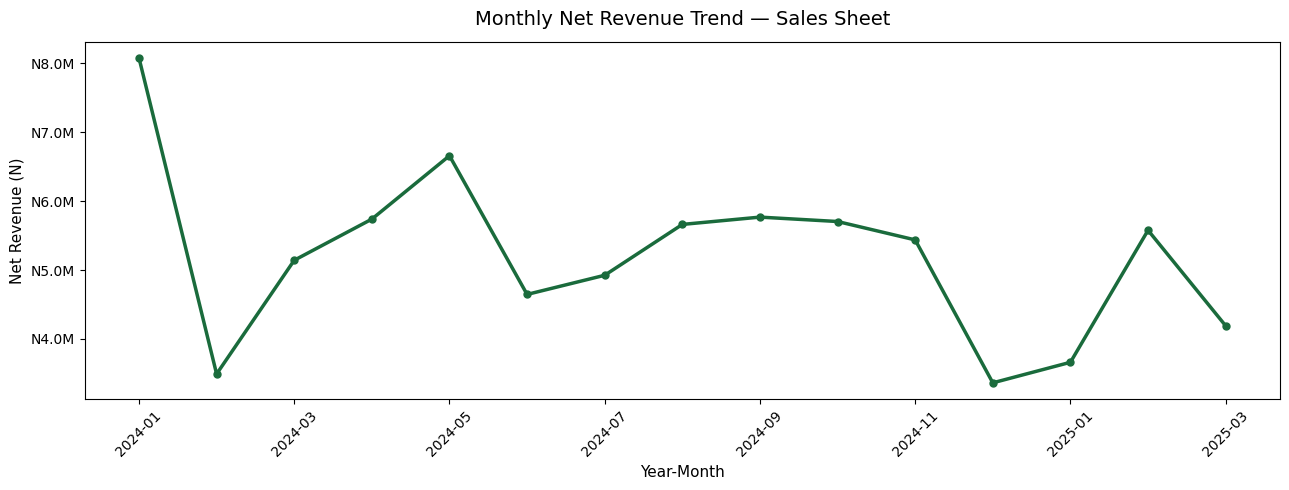

In [36]:
# Monthly revenue trend chart
monthly_rev = df_final.groupby('YearMonth')['NetRevenue'].sum()
# Group by year-month label and sum revenue for each month

fig, ax = plt.subplots(figsize=(13, 5))
# fig = the figure (canvas); ax = the axes (plot area); figsize=(width, height) in inches

monthly_rev.plot(
    kind='line',          # line chart — best for showing trends over time
    ax=ax,                # draw on our ax object
    color='#1a6b3c',      # dark green — hex colour code
    linewidth=2.5,        # line thickness
    marker='o',           # add a circle dot at each data point
    markersize=5          # size of the dot
)

ax.set_title('Monthly Net Revenue Trend — Sales Sheet', fontsize=14, pad=12)
# set_title() sets the chart title; fontsize controls text size; pad = space above plot

ax.set_xlabel('Year-Month', fontsize=11)   # label the x-axis
ax.set_ylabel('Net Revenue (N)', fontsize=11)  # label the y-axis

ax.tick_params(axis='x', rotation=45)
# tick_params() controls axis tick marks; rotation=45 tilts x labels 45° for readability

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))
# Formats y-axis ticks: 5,000,000 → 'N5.0M' (more readable than raw numbers)

plt.tight_layout()  # automatically adjusts spacing so nothing is clipped
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')  # save as PNG
plt.show()  # display the chart in the notebook

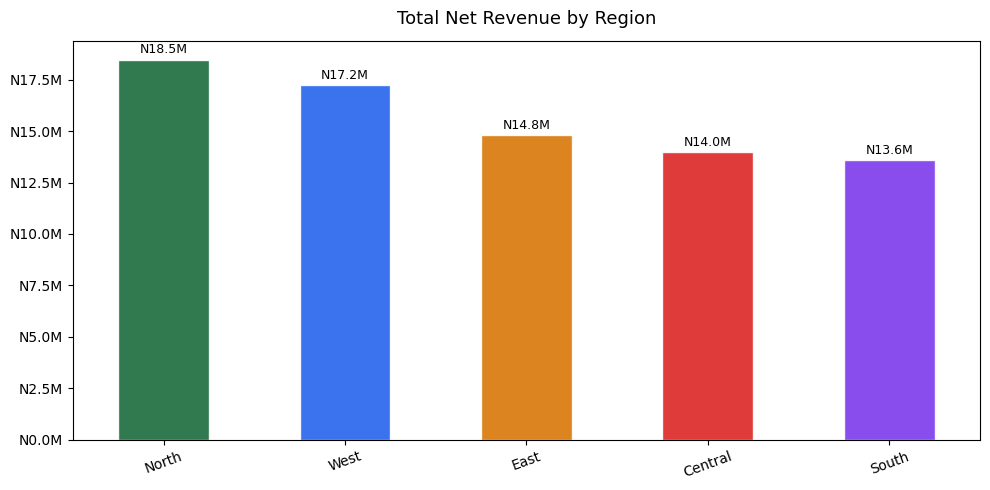

In [37]:
# Bar chart — Revenue by Region
region_data = df_final.groupby('Region')['NetRevenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#1a6b3c','#2563eb','#d97706','#dc2626','#7c3aed']  # one colour per bar
region_data.plot(kind='bar', ax=ax, color=colors, edgecolor='white', alpha=0.9)
# kind='bar' — vertical bar chart
# edgecolor='white' — white border around each bar for visual separation
# alpha=0.9 — slight transparency (0=invisible, 1=solid)

ax.set_title('Total Net Revenue by Region', fontsize=13, pad=12)
ax.set_xlabel('')           # remove x-axis label (region names are self-explanatory)
ax.tick_params(axis='x', rotation=20)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))

# Add value labels on top of each bar
for bar in ax.patches:           # ax.patches is a list of all bar objects
    h = bar.get_height()         # get the height (value) of each bar
    ax.text(
        bar.get_x() + bar.get_width()/2,  # x position: centre of bar
        h * 1.01,                          # y position: just above the bar
        f'N{h/1e6:.1f}M',                 # the label text
        ha='center', va='bottom', fontsize=9  # alignment and font size
    )

plt.tight_layout()
plt.savefig('region_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

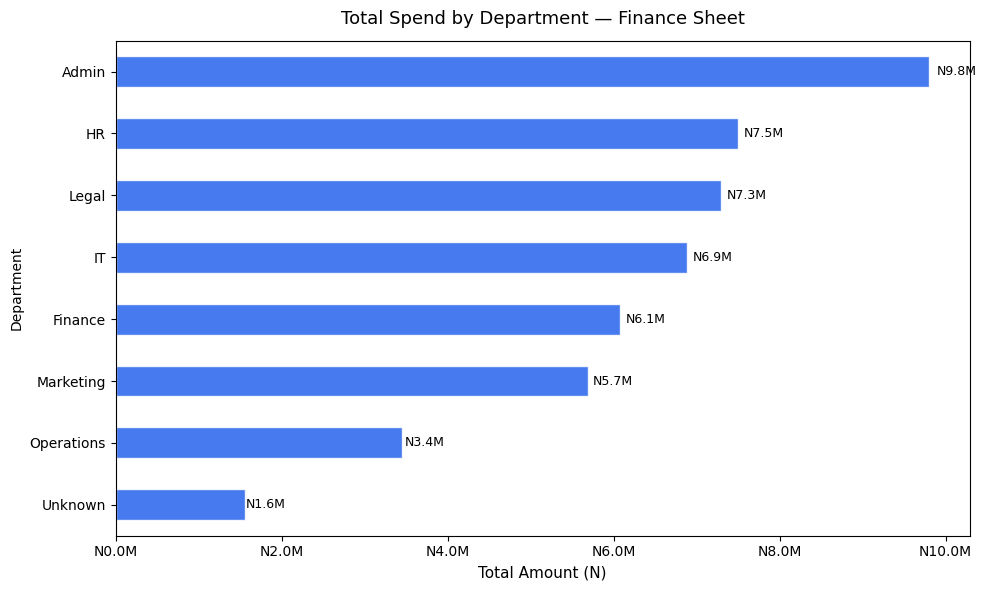

In [38]:
# Finance analysis — Department spending bar chart
df_fin_clean = pd.read_excel(
    'sample.xlsx',
    sheet_name='Finance',
    na_values=['N/A','missing','--','none'],
    parse_dates=['TransactionDate']
)
df_fin_clean.drop_duplicates(inplace=True)
df_fin_clean['Amount'] = pd.to_numeric(df_fin_clean['Amount'], errors='coerce')
df_fin_clean['Department'].fillna('Unknown', inplace=True)

dept_spend = df_fin_clean.groupby('Department')['Amount'].sum().sort_values(ascending=True)
# ascending=True so that the longest bar is at the top in a horizontal chart

fig, ax = plt.subplots(figsize=(10, 6))
dept_spend.plot(kind='barh', ax=ax, color='#2563eb', alpha=0.85, edgecolor='white')
# kind='barh' — HORIZONTAL bar chart; better when category names are long

ax.set_title('Total Spend by Department — Finance Sheet', fontsize=13, pad=12)
ax.set_xlabel('Total Amount (N)', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))

# Add value labels at the end of each horizontal bar
for bar in ax.patches:
    w = bar.get_width()    # for horizontal bars, width = the value (not height)
    ax.text(w * 1.01, bar.get_y() + bar.get_height()/2,  # position to the right of bar, centred
            f'N{w/1e6:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('dept_spend.png', dpi=150, bbox_inches='tight')
plt.show()

---
# SECTION 16: Reading Efficiently — `pd.ExcelFile` Context Manager

---

### Line-by-Line Explanation

```python
with pd.ExcelFile('sample.xlsx') as xf:
```
**`with ... as xf:`** — a Python context manager. It:
1. Opens the file and stores the handle in `xf`  
2. Automatically closes the file when the `with` block ends — even if an error occurs  

**Why use this instead of calling `pd.read_excel()` multiple times?**  
Each call to `pd.read_excel()` opens the file, reads it, and closes it. If you need 3 sheets, the file is opened and closed 3 times.  
With `pd.ExcelFile`, the file is opened **once**, all sheets are parsed, then it is closed **once**. Faster and more efficient.

---

```python
    df_s = xf.parse('Sales',   na_values=[...], parse_dates=['OrderDate'])
    df_f = xf.parse('Finance', na_values=[...], parse_dates=['TransactionDate'])
    df_h = xf.parse('Health',  na_values=[...], parse_dates=['AdmissionDate','DischargeDate'])
```
**`xf.parse('SheetName', ...)`** — reads one sheet from the already-open workbook.  
`xf.parse()` accepts all the same parameters as `pd.read_excel()` — `na_values`, `parse_dates`, `usecols`, `nrows`, etc.  
The three sheets are read in sequence from the same open file handle — very efficient.

In [39]:
# Efficient loading — open the file ONCE, read all sheets from it
# 'with' is a context manager: opens the file, runs the block, closes it automatically

with pd.ExcelFile('sample.xlsx') as xf:
    # xf is the file handle — the workbook is open for the duration of this block
    
    df_s = xf.parse('Sales',
                    na_values=['N/A','Unknown','missing'],       # dirty strings → NaN
                    parse_dates=['OrderDate'])                   # parse as datetime
    
    df_f = xf.parse('Finance',
                    na_values=['N/A','missing','--'],
                    parse_dates=['TransactionDate'])
    
    df_h = xf.parse('Health',
                    na_values=['not recorded','N/A','--'],
                    parse_dates=['AdmissionDate','DischargeDate'])
# File is automatically closed here when the 'with' block ends

print("All sheets loaded efficiently:")
print(f"  Sales   : {df_s.shape}")   # (320, 13)
print(f"  Finance : {df_f.shape}")   # (215, 10)
print(f"  Health  : {df_h.shape}")   # (265, 13)

All sheets loaded efficiently:
  Sales   : (320, 13)
  Finance : (215, 10)
  Health  : (265, 13)


---
# SECTION 17: The Complete Cleaning Pipeline — All in One Place

---

This is the professional way to write data loading and cleaning code:  
**load → clean → enrich → analyse** — all in a clear, sequential pipeline.  
Read every line carefully — this summarises everything we have covered.

In [40]:
# ═══════════════════════════════════════════════════════════════
# COMPLETE PIPELINE: Load → Clean → Enrich → Summarise
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

# ── STEP 1: LOAD ─────────────────────────────────────────────
df = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',             # load the Sales sheet by name
    parse_dates=['OrderDate'],      # auto-convert OrderDate to datetime
    na_values=['N/A','Unknown','missing','MISSING','--','none']  # dirty strings → NaN
)

# ── STEP 2: REMOVE DUPLICATES ────────────────────────────────
df.drop_duplicates(inplace=True)    # remove exact duplicate rows
df.reset_index(drop=True, inplace=True)  # renumber the row index cleanly

# ── STEP 3: FILL MISSING VALUES ─────────────────────────────
df['SalesRep'].fillna(df['SalesRep'].mode()[0], inplace=True)    # most frequent rep
df['UnitPrice'].fillna(df['UnitPrice'].median(), inplace=True)   # median price
df['TotalAmount'].fillna(df['TotalAmount'].median(), inplace=True) # median total
df['Customer'].fillna('Walk-in Customer', inplace=True)           # constant fill
df['Rating'].fillna(df['Rating'].median(), inplace=True)         # median rating

# ── STEP 4: FIX DATA TYPES ──────────────────────────────────
df['Discount_Pct'] = pd.to_numeric(df['Discount_Pct'], errors='coerce').fillna(0)
# convert to number; 'missing' strings become NaN (then filled with 0)

# ── STEP 5: CLEAN STRINGS ────────────────────────────────────
df['Region']   = df['Region'].str.strip().str.title()    # remove spaces, title-case
df['Status']   = df['Status'].str.strip().str.title()    # standardise status values
df['Channel']  = df['Channel'].str.strip().str.title()
df['SalesRep'] = df['SalesRep'].str.strip()              # just remove whitespace

# ── STEP 6: ADD DERIVED COLUMNS ──────────────────────────────
df['GrossRevenue']  = df['UnitPrice'] * df['Quantity']               # before discount
df['DiscountAmount'] = df['GrossRevenue'] * (df['Discount_Pct'] / 100)  # discount in NGN
df['NetRevenue']    = df['GrossRevenue'] - df['DiscountAmount']      # after discount
df['YearMonth']     = df['OrderDate'].dt.to_period('M').astype(str)  # 'YYYY-MM' label
df['IsHighValue']   = df['NetRevenue'] > df['NetRevenue'].median()   # True/False flag

# ── STEP 7: VERIFY ───────────────────────────────────────────
remaining_null = df.isnull().sum().sum()  # total missing values across all columns
print("=== Pipeline Complete ===")
print(f"Shape           : {df.shape}")
print(f"Missing values  : {remaining_null}")
print(f"Duplicates      : {df.duplicated().sum()}")
print()
print("Final dtypes:")
print(df.dtypes)

=== Pipeline Complete ===
Shape           : (300, 18)
Missing values  : 0
Duplicates      : 0

Final dtypes:
OrderID                   object
OrderDate         datetime64[ns]
Customer                  object
Region                    object
SalesRep                  object
Channel                   object
Product                   object
Quantity                   int64
UnitPrice                float64
Discount_Pct             float64
TotalAmount              float64
Status                    object
Rating                   float64
GrossRevenue             float64
DiscountAmount           float64
NetRevenue               float64
YearMonth                 object
IsHighValue                 bool
dtype: object


In [ ]:
# ── FINAL SUMMARY TABLE ─────────────────────────────────────────
summary = df.groupby('Product').agg(
    Orders     = ('OrderID',    'count'),
    Gross_Rev  = ('GrossRevenue','sum'),
    Discount   = ('DiscountAmount','sum'),
    Net_Rev    = ('NetRevenue', 'sum'),
    Avg_Rating = ('Rating',     'mean')
).round(0).sort_values('Net_Rev', ascending=False)

print("=== Final Product Summary — Cleaned Data ===")
print(summary.to_string())  # .to_string() prevents truncation of rows/columns

=== Final Product Summary — Cleaned Data ===
          Orders     Gross_Rev     Discount       Net_Rev  Avg_Rating
Product                                                              
Laptop        38 29,623,478.00 1,655,726.00 27,967,752.00        3.00
Tablet        42 17,411,637.00 1,354,181.00 16,057,456.00        3.00
Monitor       39 13,043,674.00   646,495.00 12,397,178.00        3.00
Printer       32  9,675,467.00   608,208.00  9,067,259.00        3.00
Phone         41  8,876,110.00   824,264.00  8,051,846.00        3.00
Router        40  4,454,523.00   359,662.00  4,094,860.00        3.00
Headset       39  3,024,192.00   140,117.00  2,884,075.00        3.00
Keyboard      29  1,586,958.00   162,653.00  1,424,306.00        4.00


: 

---
# SECTION 18: Quick Reference Cheat Sheet

---

## `pd.read_excel()` — Every Key Parameter

```python
pd.read_excel(
    'file.xlsx',                         # file path — REQUIRED
    sheet_name=0,                        # 0=first, 'Name', ['A','B'], None=all
    header=0,                            # row number for column headers (0-indexed)
    index_col=None,                      # column to use as the row index
    usecols=['col1','col2'],             # load only these columns
    usecols='A:D',                       # or use Excel column letter range
    dtype={'ID': str, 'Qty': int},       # force column data types
    na_values=['N/A','missing','--'],    # treat these strings as NaN
    skiprows=3,                          # skip first n rows (title rows)
    skiprows=[0, 2],                     # or skip specific row numbers
    nrows=100,                           # load only first n data rows
    parse_dates=['date_col'],            # auto-convert to datetime
    engine='openpyxl',                   # openpyxl for .xlsx; xlrd for .xls
)
```

---

## Data Cleaning — Every Command Used in This Notebook

```python
# INSPECT
df.info()                              # types + missing count per column
df.isnull().sum()                      # missing count per column
df.duplicated().sum()                  # number of duplicate rows
df.describe()                          # statistical summary (spot outliers in min/max)
df['col'].value_counts(dropna=False)   # frequency of each value (including NaN)
df['col'].unique()                     # all unique values
df['col'].nunique()                    # count of unique values

# MISSING VALUES
df['col'].fillna(df['col'].median())   # fill with median
df['col'].fillna(df['col'].mode()[0])  # fill with mode (most frequent)
df['col'].fillna('constant')           # fill with a constant string
df['col'].ffill()                      # forward fill (time series)
df.dropna(subset=['col'])              # drop rows where col is NaN

# DUPLICATES
df.drop_duplicates(keep='first')       # remove duplicate rows, keep first
df.reset_index(drop=True, inplace=True) # renumber index after removing rows

# DATA TYPES
pd.to_datetime(df['col'])              # convert to datetime
pd.to_numeric(df['col'], errors='coerce') # convert to number, NaN on failure
df['col'].astype('float64')            # force a specific type

# DIRTY / OUTLIER VALUES
df.loc[df['col'] > max_valid, 'col'] = np.nan  # replace impossible values with NaN

# STRING CLEANING
df['col'].str.strip()                  # remove leading/trailing whitespace
df['col'].str.title()                  # 'north' → 'North'
df['col'].str.lower()                  # all lowercase
df['col'].str.upper()                  # ALL UPPERCASE
df['col'].str.contains('text', na=False) # True/False: does the cell contain 'text'?
df['col'].str.replace('old', 'new')    # replace substring

# DATETIME (after parse_dates or pd.to_datetime)
df['col'].dt.year                      # extract year
df['col'].dt.month                     # extract month number
df['col'].dt.month_name()              # 'January', 'February'...
df['col'].dt.day_name()                # 'Monday', 'Tuesday'...
df['col'].dt.quarter                   # 1, 2, 3, or 4
df['col'].dt.to_period('M').astype(str) # 'YYYY-MM' label for grouping

# DERIVED COLUMNS
df['new'] = df['a'] * df['b']                        # arithmetic
df['new'] = np.where(condition, val_true, val_false) # conditional (like Excel IF)

# GROUPBY + AGGREGATION
df.groupby('col')['value'].sum()
df.groupby('col').agg(
    new_name = ('source_col', 'function')            # named aggregation
)

# PIVOT TABLE
pd.pivot_table(df, values, index, columns, aggfunc='sum', fill_value=0)
```

---

> *"Every cell you clean, every NaN you fill, every duplicate you remove — you are making your analysis more honest."*  
> — **Prodigy Training Hub**

---